In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
from pandas import read_csv
df=read_csv("placement_predict_50k Dataset.csv")


In [8]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly', 'Salary Package']
Categorical Features: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [9]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [10]:
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                    StudentID  SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  SGPA_Sem4  \
StudentID            1.000000  -0.005045  -0.004739  -0.004352  -0.002862   
SGPA_Sem1           -0.005045   1.000000   0.963906   0.963731   0.963647   
SGPA_Sem2           -0.004739   0.963906   1.000000   0.964888   0.964847   
SGPA_Sem3           -0.004352   0.963731   0.964888   1.000000   0.965633   
SGPA_Sem4           -0.002862   0.963647   0.964847   0.965633   1.000000   
SGPA_Sem5           -0.003535   0.963033   0.964724   0.965470   0.966522   
SGPA_Sem6           -0.003299   0.962380   0.964242   0.965803   0.966468   
SGPA_Sem7           -0.003609   0.961857   0.963915   0.965449   0.966285   
SGPA_Sem8           -0.003976   0.960526   0.962965   0.964722   0.966092   
CGPA                -0.003395   0.911150   0.912419   0.912881   0.913410   
AttendancePercent    0.001042   0.497033   0.506549   0.514306   0.522507   
Internships         -0.001224   0.445559   0.455

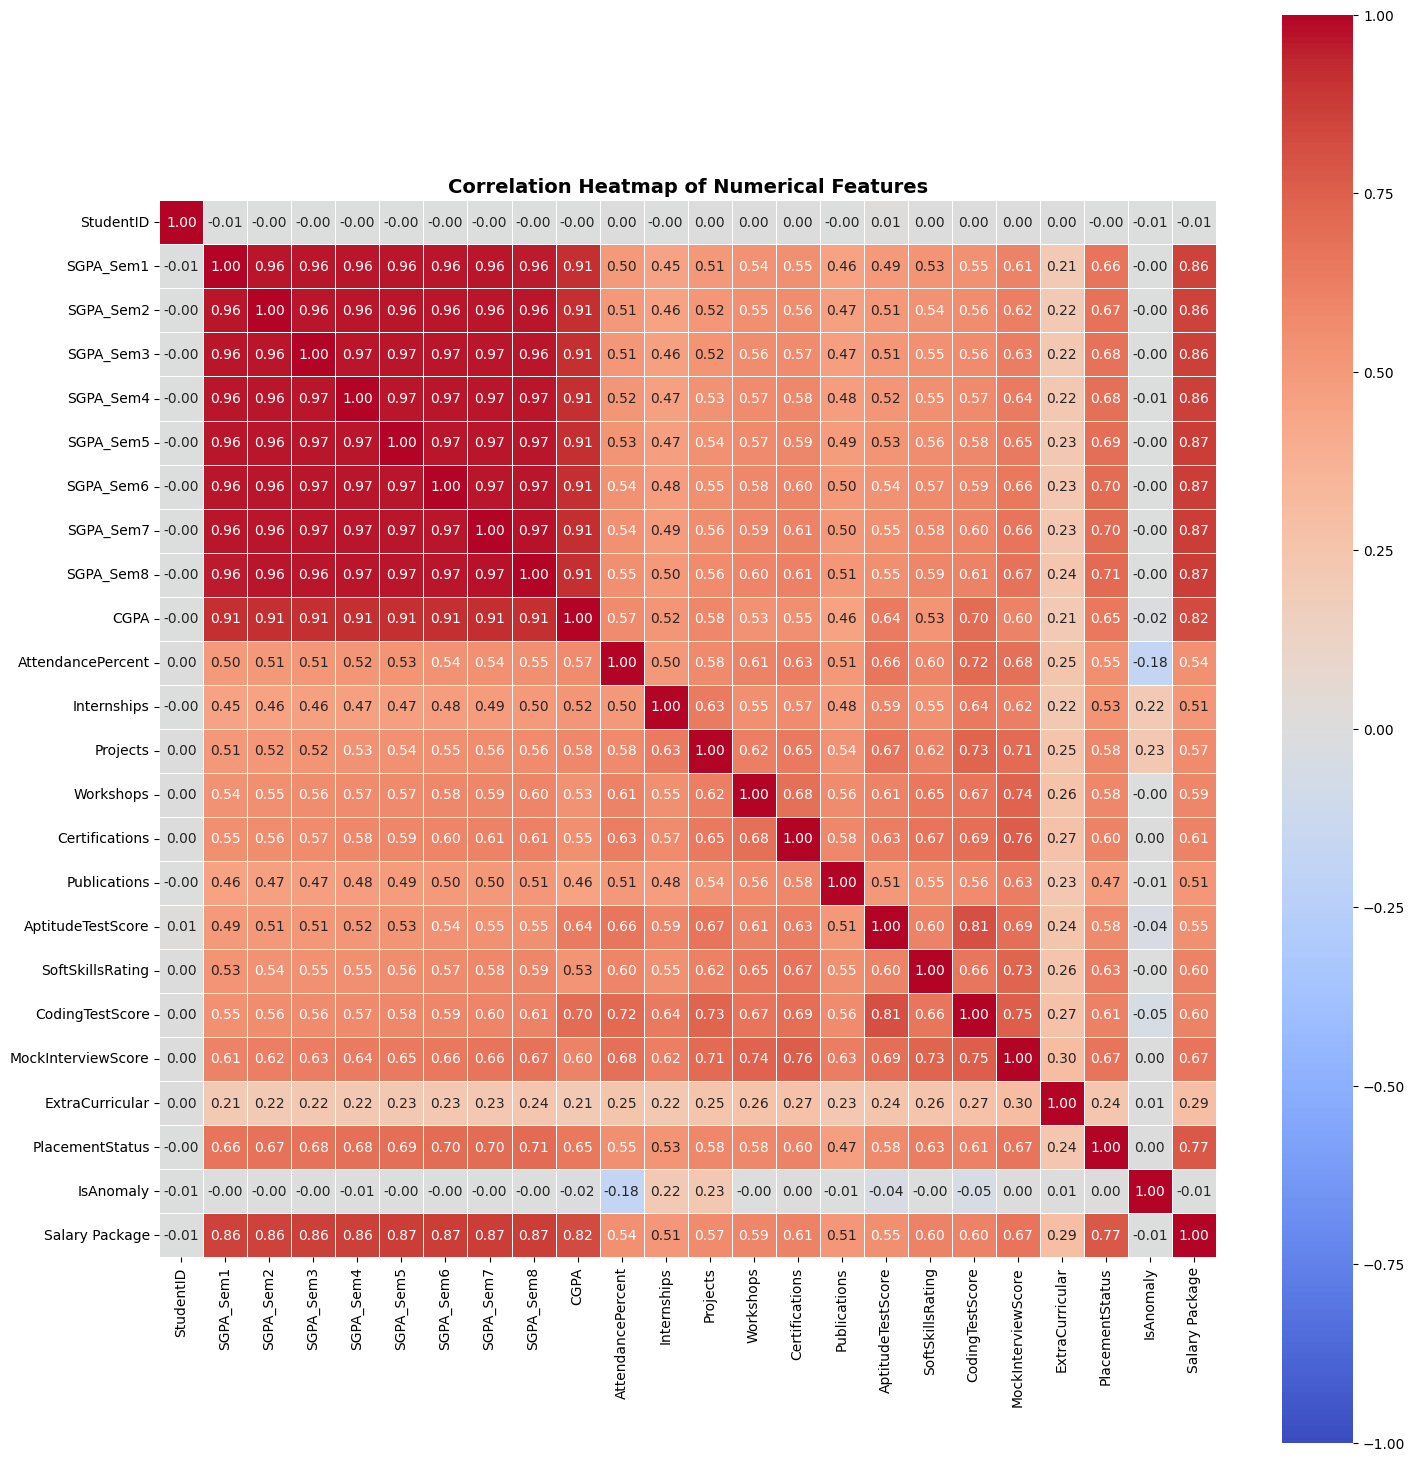

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [12]:
import os
output_dir = "reports"
os.makedirs(output_dir, exist_ok=True)
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")

plt.savefig(heatmap_path, dpi=300)
plt.close()

print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: reports/correlation_heatmap.png


In [13]:
target_col = "PlacementStatus"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()


        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")

    else:
        print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

        print("\nAll EDA tasks completed successfully!")



Exported boxplot to: reports/boxplot_StudentID_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_SGPA_Sem1_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_SGPA_Sem2_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_SGPA_Sem3_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_SGPA_Sem4_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_SGPA_Sem5_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_SGPA_Sem6_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_SGPA_Sem7_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_SGPA_Sem8_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_CGPA_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_AttendancePercent_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_Internships_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_Projects_vs_PlacementStatus.png
Exported boxplot to: reports/boxplot_Workshops_vs_PlacementStatus.png
Exported boxplot

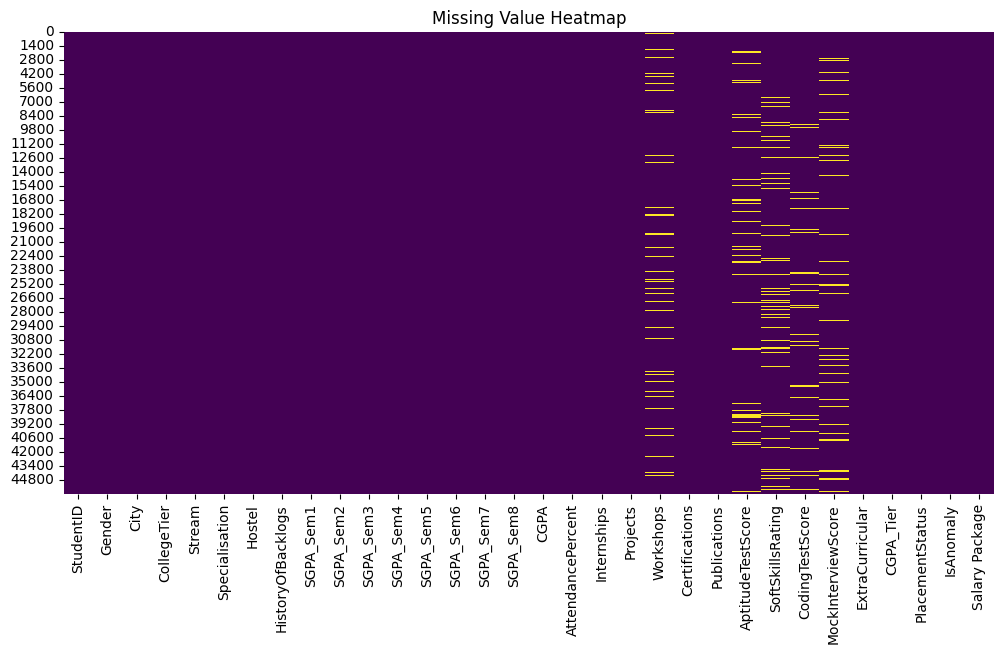

In [14]:
import matplotlib.pyplot as plt
fig1=plt.figure(figsize=(12,6))

sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

<Figure size 1500x800 with 0 Axes>

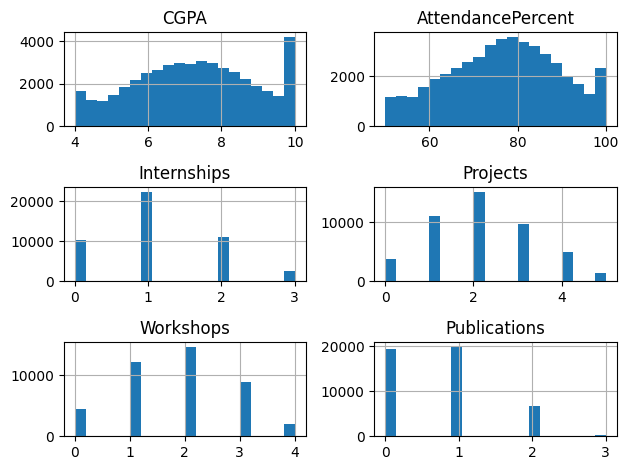

In [15]:
features = ["CGPA", "AttendancePercent", "Internships", "Projects","Workshops", "Publications" ]

fig2=plt.figure(figsize=(15,8))
df[features].hist(
    bins=20
)

plt.tight_layout()

plt.show()

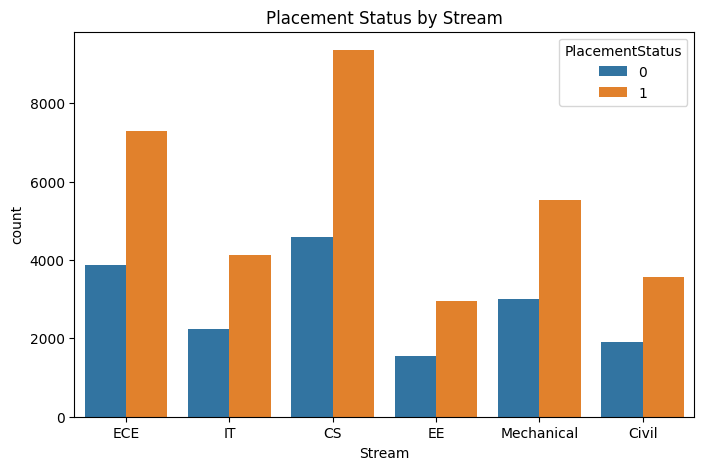

In [20]:
fig3 = plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Stream",
    hue="PlacementStatus"
)

plt.title("Placement Status by Stream")
plt.show()

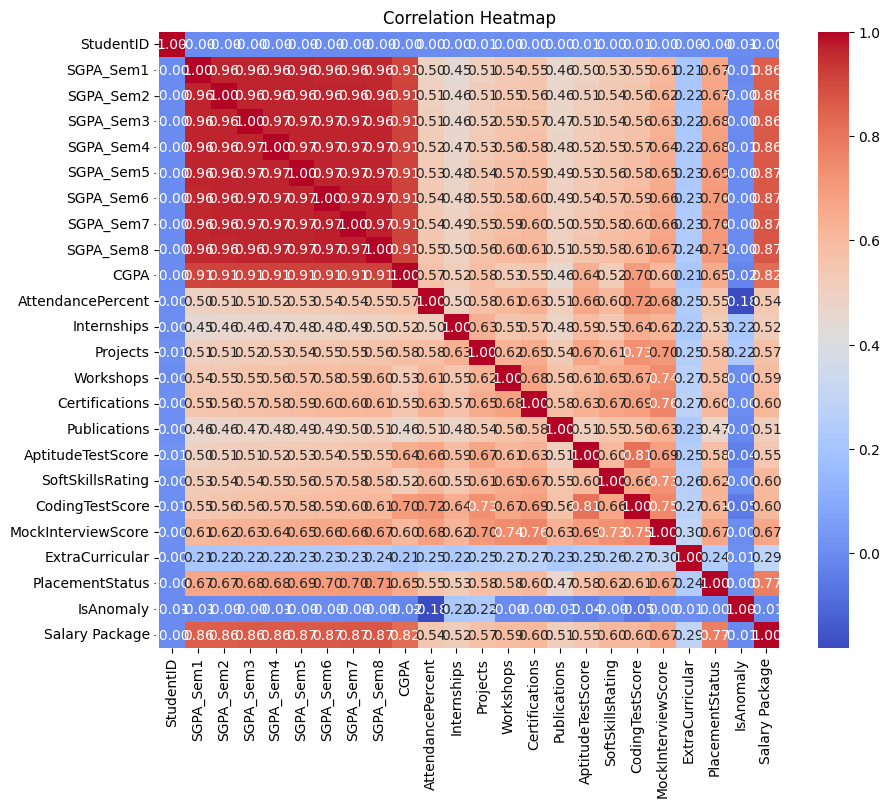

In [21]:
#Corelation Heatmap

fig5= plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

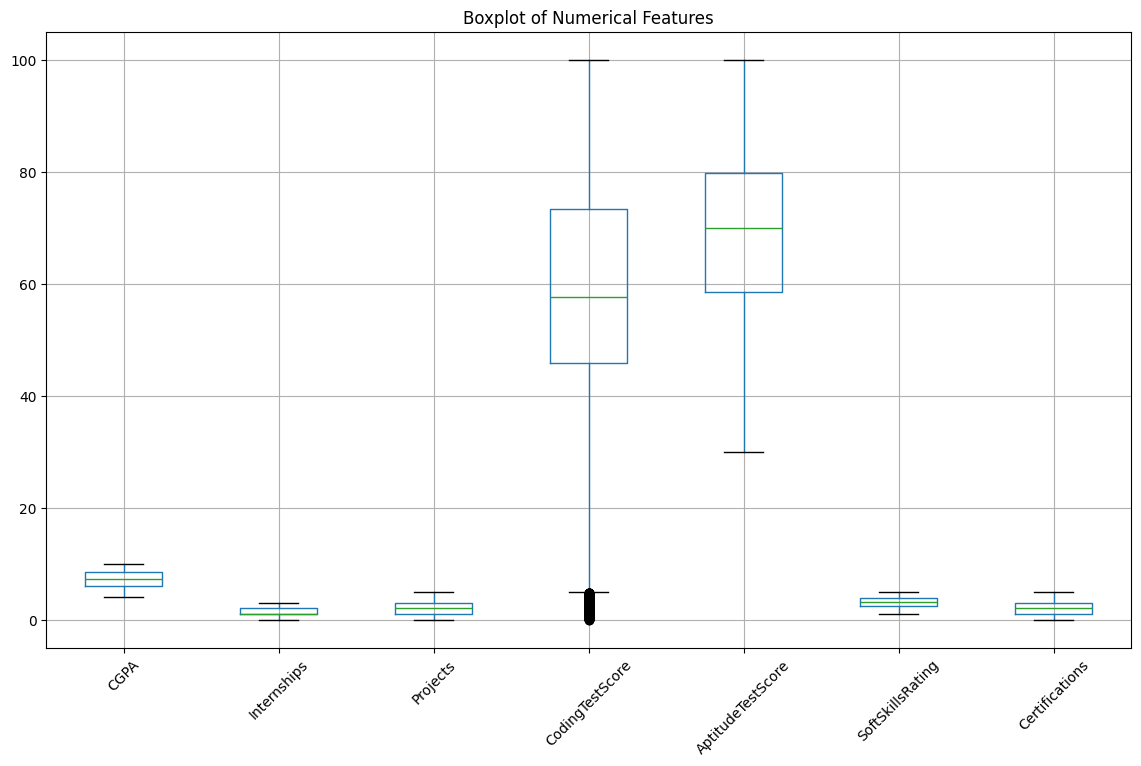

In [22]:
numerical_columns = [
    "CGPA",
    "Internships",
    "Projects",
    "CodingTestScore",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "Certifications",
    "HistoryOfBacklogs"
]

fig6 = plt.figure(figsize=(14,8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

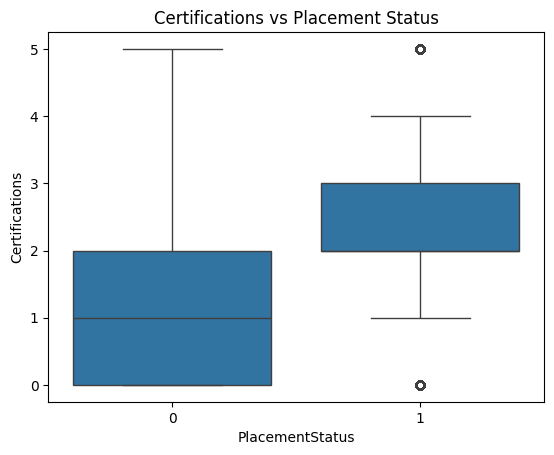

In [23]:
fig7 = sns.boxplot(
    x="PlacementStatus",
    y="Certifications",
    data=df
)

plt.title("Certifications vs Placement Status")
plt.show()

In [24]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)


print("EDA Report saved successfully.")

EDA Report saved successfully.


In [27]:
# ==========================================================
# COMPLETE EDA REPORT - PLACEMENT PREDICTION DATASET
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import read_csv
from matplotlib.backends.backend_pdf import PdfPages

# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------

df = read_csv("placement_predict_50k Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ----------------------------------------------------------
# 2. DEFINE FEATURES
# ----------------------------------------------------------

numerical_features = [
    "CGPA",
    "AttendancePercent",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

print("\nSelected numerical features:")
print(numerical_features)


# ----------------------------------------------------------
# 3. CREATE EDA PDF REPORT
# ----------------------------------------------------------

with PdfPages("EDA_Report.pdf") as pdf:

    # ======================================================
    # PAGE 1 : MISSING VALUE HEATMAP
    # ======================================================

    print("\nCreating Page 1: Missing Value Heatmap...")

    plt.figure(figsize=(12, 6))

    # Use only 2,000 rows to make the heatmap faster
    sample_df = df.sample(
        min(2000, len(df)),
        random_state=42
    )

    sns.heatmap(
        sample_df.isnull(),
        cbar=False,
        yticklabels=False,
        cmap="viridis"
    )

    plt.title("Missing Value Heatmap")
    plt.xlabel("Features")
    plt.ylabel("Samples")

    plt.tight_layout()

    pdf.savefig()
    plt.close()


    # ======================================================
    # PAGE 2 : HISTOGRAMS
    # ======================================================

    print("Creating Page 2: Histograms...")

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(14, 12)
    )

    axes = axes.flatten()

    for i, col in enumerate(numerical_features):

        axes[i].hist(
            df[col].dropna(),
            bins=20,
            edgecolor="black"
        )

        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    plt.tight_layout()

    pdf.savefig()
    plt.close()


    # ======================================================
    # PAGE 3 : PLACEMENT STATUS BY STREAM
    # ======================================================

    print("Creating Page 3: Placement Status by Stream...")

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="Stream",
        hue="PlacementStatus"
    )

    plt.title("Placement Status by Stream")
    plt.xlabel("Stream")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=45)

    plt.tight_layout()

    pdf.savefig()
    plt.close()


    # ======================================================
    # PAGE 4 : CORRELATION HEATMAP
    # ======================================================

    print("Creating Page 4: Correlation Heatmap...")

    plt.figure(figsize=(12, 10))

    correlation_columns = df.select_dtypes(
        include=np.number
    ).columns.tolist()

    # StudentID is only an identifier
    if "StudentID" in correlation_columns:
        correlation_columns.remove("StudentID")

    corr = df[correlation_columns].corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5
    )

    plt.title("Correlation Heatmap")

    plt.tight_layout()

    pdf.savefig()
    plt.close()


    # ======================================================
    # PAGE 5 : BOXPLOTS
    # ======================================================

    print("Creating Page 5: Boxplots...")

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(14, 12)
    )

    axes =axes.flatten()

    for i, col in enumerate(numerical_features):

        sns.boxplot(
            y=df[col],
            ax=axes[i]
        )

        axes[i].set_title(col)
        axes[i].set_ylabel(col)

    plt.tight_layout()

    pdf.savefig()
    plt.close()


    # ======================================================
    # PAGE 6 : CERTIFICATIONS VS PLACEMENT STATUS
    # ======================================================

    print("Creating Page 6: Certifications vs Placement Status...")

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x="PlacementStatus",
        y="Certifications",
        data=df
    )

    plt.title("Certifications vs Placement Status")
    plt.xlabel("Placement Status")
    plt.ylabel("Certifications")

    plt.tight_layout()

    pdf.savefig()
    plt.close()


# ==========================================================
# REPORT COMPLETED
# ==========================================================

print("\n==========================================")
print("EDA_Report.pdf created successfully!")
print("==========================================")

Dataset loaded successfully!
Shape: (50000, 32)

Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Selected numerical features:
['CGPA', 'AttendancePercent', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']

Creating Page 1: Missing Value Heatmap...
Creating Page 2: Histograms...
Creating Page 3: Placement Status by Stream...
Creating Page 4: Correlation Heatmap...
Creating Page 5: Boxplots...
Creating Page 6: Certifications vs Placement Status...

EDA_Report.pdf created successfully!
